<a href="https://colab.research.google.com/github/ablavi-cl/IACC_Semana08/blob/main/Alejandra_BlaviUnidad3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Proyecto de análisis de datos – AquaLimpia S. A.

## Objetivo

Analizar el desempeño de las plantas de tratamiento a partir de los datos disponibles, considerando variables relacionadas con el proceso y el cumplimiento de norma.

## Preguntas de investigación

1. ¿Cómo puede abordarse analíticamente la problemática descrita para apoyar la toma de decisiones en AquaLimpia S. A.?

2. ¿Cómo debería estructurarse un flujo de trabajo reproducible para analizar
el desempeño de las plantas y facilitar la continuidad del proyecto?

3. ¿De qué manera la documentación técnica contribuye a la comprensión, trazabilidad y continuidad del proyecto?

4. ¿Qué ventajas ofrece el uso de scripts reutilizables y código modular para este tipo de análisis?

5. ¿Qué riesgos pueden surgir si los datos presentan problemas de calidad y cuáles son las principales limitaciones del dataset utilizado?

6. ¿Cómo puede organizarse el proyecto mediante un repositorio Git que integre el notebook, los datos, los dashboards y la documentación técnica?

## Metodología

1. Carga y revisión del dataset.
2. Revisión de la estructura y calidad de los datos.
3. Análisis de las variables agrupadas por planta.
4. Cálculo de promedios y porcentajes.
5. Generación de visualizaciones.
6. Construcción del dashboard exploratorio.
7. Organización de los archivos y documentación del proyecto.

## Resultados

El análisis permitió comparar el desempeño de las plantas considerando DBO de entrada y salida, caudal, energía de aireación y cumplimiento de norma.

La Planta Sur presentó el mayor porcentaje de cumplimiento, mientras que la Planta Norte presentó el menor porcentaje. Además, se generó un dashboard exploratorio para facilitar la comparación de los resultados.

## Herramientas utilizadas

- Python
- Pandas
- NumPy
- SciPy
- Joblib
- Plotly
- Google Colab
- Git/GitHub

In [16]:
import pandas as pd
df = pd.read_excel("dataset_set_A_aguas_residuales.xlsx")
df.head()

,fecha_registro,planta,caudal_entrada_m3_d,DBO_entrada_mg_L,SST_entrada_mg_L,pH_entrada,energia_aeracion_kWh,lodos_generados_kg_d,DBO_salida_mg_L,cumplimiento_norma
0,2025-08-17,Planta Sur,6562,271,324,7.12,1261.1,440.3,40.0,0
1,2025-09-07,Planta Sur,5336,322,230,7.01,1629.3,561.2,26.8,1
2,2025-07-26,Planta Norte,5755,318,282,6.79,1469.2,441.6,45.2,0
3,2025-10-27,Planta Centro,6840,216,167,7.01,1764.8,560.0,38.0,0
4,2025-09-06,Planta Centro,6803,326,200,7.55,1409.3,654.0,32.1,0


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fecha_registro        200 non-null    object 
 1   planta                200 non-null    object 
 2   caudal_entrada_m3_d   200 non-null    int64  
 3   DBO_entrada_mg_L      200 non-null    int64  
 4   SST_entrada_mg_L      200 non-null    int64  
 5   pH_entrada            200 non-null    float64
 6   energia_aeracion_kWh  200 non-null    float64
 7   lodos_generados_kg_d  200 non-null    float64
 8   DBO_salida_mg_L       200 non-null    float64
 9   cumplimiento_norma    200 non-null    int64  
dtypes: float64(4), int64(4), object(2)
memory usage: 15.8+ KB


In [18]:
df.groupby("planta")[[
    "caudal_entrada_m3_d",
    "DBO_entrada_mg_L",
    "DBO_salida_mg_L",
    "energia_aeracion_kWh",
    "lodos_generados_kg_d",
    "cumplimiento_norma"]].mean()

,caudal_entrada_m3_d,DBO_entrada_mg_L,DBO_salida_mg_L,energia_aeracion_kWh,lodos_generados_kg_d,cumplimiento_norma
planta,,,,,,
Planta Centro,5112.720000,285.186667,35.901333,1260.854667,433.010667,0.226667
Planta Norte,5287.873239,275.845070,36.560563,1299.308451,450.471831,0.169014
Planta Sur,4684.518519,278.796296,36.057407,1193.775926,394.440741,0.296296


In [19]:
pd.crosstab(df["planta"], df["cumplimiento_norma"])

cumplimiento_norma,0,1
planta,,
Planta Centro,58,17
Planta Norte,59,12
Planta Sur,38,16


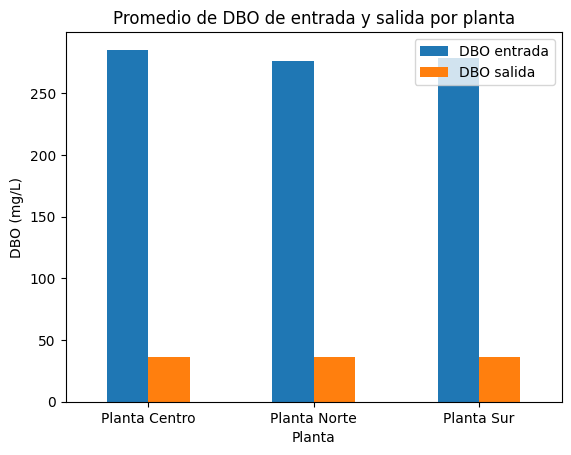

In [25]:
import matplotlib.pyplot as mat
dbo_por_planta = df.groupby("planta")[[
    "DBO_entrada_mg_L",
    "DBO_salida_mg_L"
]].mean()

dbo_por_planta.plot(kind="bar")

mat.title("Promedio de DBO de entrada y salida por planta")
mat.xlabel("Planta")
mat.ylabel("DBO (mg/L)")
mat.xticks(rotation=0)
mat.legend(["DBO entrada", "DBO salida"])
mat.show()

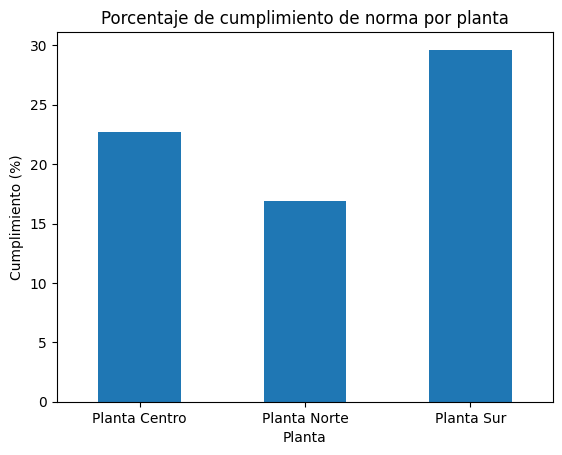

In [21]:
cumplimiento_por_planta = df.groupby("planta")["cumplimiento_norma"].mean() * 100

cumplimiento_por_planta.plot(kind="bar")

mat.title("Porcentaje de cumplimiento de norma por planta")
mat.xlabel("Planta")
mat.ylabel("Cumplimiento (%)")
mat.xticks(rotation=0)
mat.show()

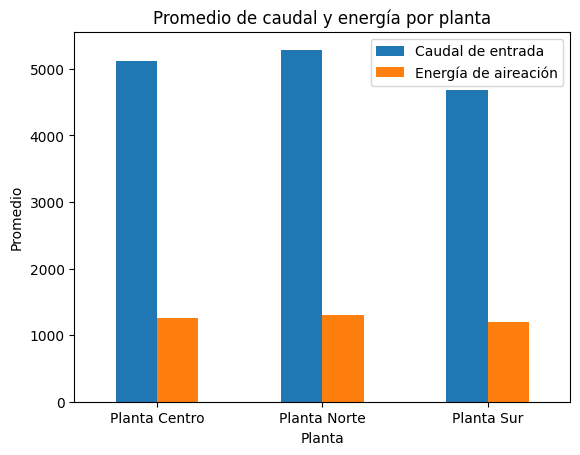

In [22]:
caudal_energia = df.groupby("planta")[[
    "caudal_entrada_m3_d",
    "energia_aeracion_kWh"
]].mean()

caudal_energia.plot(kind="bar")

mat.title("Promedio de caudal y energía por planta")
mat.xlabel("Planta")
mat.ylabel("Promedio")
mat.xticks(rotation=0)
mat.legend(["Caudal de entrada", "Energía de aireación"])
mat.show()

In [34]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

dbo_por_planta = df.groupby("planta")[[
    "DBO_entrada_mg_L",
    "DBO_salida_mg_L"
]].mean()

cumplimiento_por_planta = df.groupby("planta")[
    "cumplimiento_norma"
].mean() * 100

caudal_por_planta = df.groupby("planta")[
    "caudal_entrada_m3_d"
].mean()

energia_por_planta = df.groupby("planta")[
    "energia_aeracion_kWh"
].mean()

fig = make_subplots(
    rows=2,
    cols=2,
    subplot_titles=(
        "Promedio de DBO de entrada y salida",
        "Porcentaje de cumplimiento de norma",
        "Promedio de caudal de entrada",
        "Promedio de energía de aireación"
    )
)

fig.add_trace(
    go.Bar(
        x=dbo_por_planta.index,
        y=dbo_por_planta["DBO_entrada_mg_L"],
        name="DBO entrada"
    ),
    row=1,
    col=1
)

fig.add_trace(
    go.Bar(
        x=dbo_por_planta.index,
        y=dbo_por_planta["DBO_salida_mg_L"],
        name="DBO salida"
    ),
    row=1,
    col=1
)

fig.add_trace(
    go.Bar(
        x=cumplimiento_por_planta.index,
        y=cumplimiento_por_planta.values,
        name="Cumplimiento (%)"
    ),
    row=1,
    col=2
)

fig.add_trace(
    go.Bar(
        x=caudal_por_planta.index,
        y=caudal_por_planta.values,
        name="Caudal"
    ),
    row=2,
    col=1
)

fig.add_trace(
    go.Bar(
        x=energia_por_planta.index,
        y=energia_por_planta.values,
        name="Energía"
    ),
    row=2,
    col=2
)

fig.update_layout(
    title_text="Dashboard exploratorio del desempeño de las plantas",
    height=700,
    showlegend=True
)

fig.show()

In [30]:
%%writefile funciones_analisis.py

import numpy as np
from scipy import stats
from joblib import dump, load


def calcular_promedio(datos):
    datos = np.array(datos)
    return np.mean(datos)


def calcular_intervalo():
    media = 125
    intervalo = stats.t.interval(0.95, df=2, loc=media, scale=1.5)
    return intervalo


def guardar_resultado(resultado, nombre_archivo):
    dump(resultado, nombre_archivo)

Writing funciones_analisis.py


In [31]:
from funciones_analisis import calcular_promedio, calcular_intervalo, guardar_resultado

promedio_dbo = calcular_promedio(df["DBO_salida_mg_L"])

intervalo = calcular_intervalo()

guardar_resultado(
    {"promedio_dbo_salida": promedio_dbo},
    "resultado_dbo.joblib"
)

print("Promedio DBO salida:", promedio_dbo)
print("Intervalo:", intervalo)

Promedio DBO salida: 36.1775
Intervalo: (np.float64(118.54602090545579), np.float64(131.45397909454422))


In [12]:
operaciones = df[[
    "fecha_registro",
    "planta",
    "caudal_entrada_m3_d",
    "DBO_entrada_mg_L",
    "DBO_salida_mg_L",
    "energia_aeracion_kWh",
    "lodos_generados_kg_d"
]]

operaciones.head()

,fecha_registro,planta,caudal_entrada_m3_d,DBO_entrada_mg_L,DBO_salida_mg_L,energia_aeracion_kWh,lodos_generados_kg_d
0,2025-08-17,Planta Sur,6562,271,40.0,1261.1,440.3
1,2025-09-07,Planta Sur,5336,322,26.8,1629.3,561.2
2,2025-07-26,Planta Norte,5755,318,45.2,1469.2,441.6
3,2025-10-27,Planta Centro,6840,216,38.0,1764.8,560.0
4,2025-09-06,Planta Centro,6803,326,32.1,1409.3,654.0


In [13]:
gestion_ambiental = df[[
    "fecha_registro",
    "planta",
    "DBO_salida_mg_L",
    "cumplimiento_norma"
]]

gestion_ambiental.head()

,fecha_registro,planta,DBO_salida_mg_L,cumplimiento_norma
0,2025-08-17,Planta Sur,40.0,0
1,2025-09-07,Planta Sur,26.8,1
2,2025-07-26,Planta Norte,45.2,0
3,2025-10-27,Planta Centro,38.0,0
4,2025-09-06,Planta Centro,32.1,0


In [35]:
operaciones.to_excel("salida_operaciones.xlsx", index=False)
gestion_ambiental.to_excel("salida_gestion_ambiental.xlsx", index=False)

print("Archivos de salida creados correctamente.")

Archivos de salida creados correctamente.
